**Sentiment Analysis**

This project analyzes text data to understand sentiment using basic natural language processing techniques.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
import nltk
from nltk.corpus import movie_reviews

nltk.download('movie_reviews')

reviews = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        text = movie_reviews.raw(fileid)
        reviews.append({
            'review': text,
            'sentiment': category
        })

df = pd.DataFrame(reviews)

df.head()

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


,review,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     2000 non-null   object
 1   sentiment  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [19]:
df['sentiment'].value_counts()

,count
sentiment,
neg,1000
pos,1000


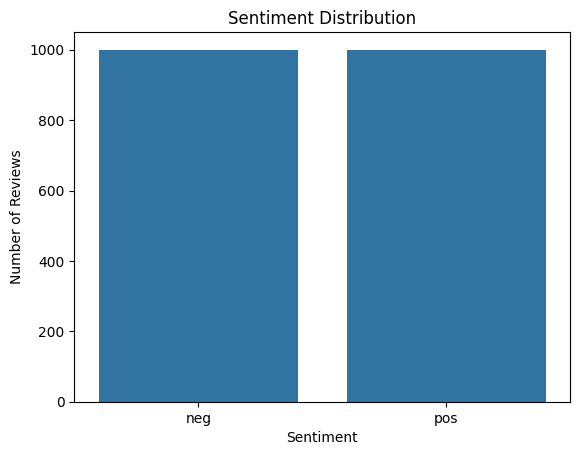

In [20]:
sns.countplot(data=df, x='sentiment')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [21]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,"plot : two teen couples go to a church party ,...",plot two teen couples go to a church party d...
1,the happy bastard's quick movie review \ndamn ...,the happy bastards quick movie review \ndamn t...
2,it is movies like these that make a jaded movi...,it is movies like these that make a jaded movi...
3,""" quest for camelot "" is warner bros . ' firs...",quest for camelot is warner bros first fe...
4,synopsis : a mentally unstable man undergoing ...,synopsis a mentally unstable man undergoing p...


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

print(X.shape)

(2000, 5000)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1600, 5000)
(400, 5000)


In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test)

y_pred[:10]

array(['neg', 'neg', 'pos', 'pos', 'neg', 'pos', 'neg', 'neg', 'neg',
       'pos'], dtype=object)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', accuracy)

Accuracy: 0.8375


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.86      0.81      0.83       200
         pos       0.82      0.86      0.84       200

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



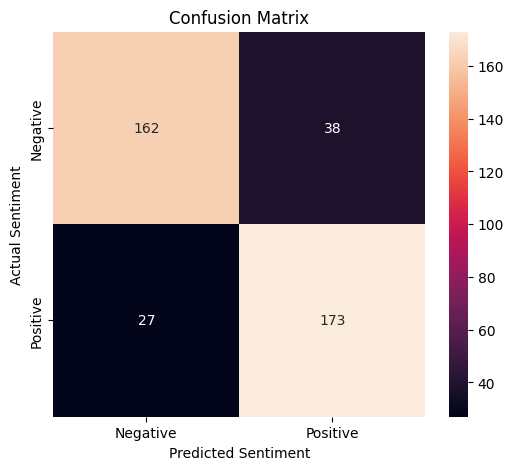

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

In [29]:
sample_reviews = [
    "This movie was amazing and I really enjoyed it.",
    "The movie was boring and disappointing."
]

sample_clean = [clean_text(review) for review in sample_reviews]

sample_features = vectorizer.transform(sample_clean)

predictions = model.predict(sample_features)

for review, sentiment in zip(sample_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print()

Review: This movie was amazing and I really enjoyed it.
Predicted Sentiment: pos

Review: The movie was boring and disappointing.
Predicted Sentiment: neg



**Conclusion**

The sentiment analysis model was trained to classify movie reviews as positive or negative. The accuracy and classification report show how well the model performs on unseen reviews.